In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.ticker as mticker
import pandas as pd


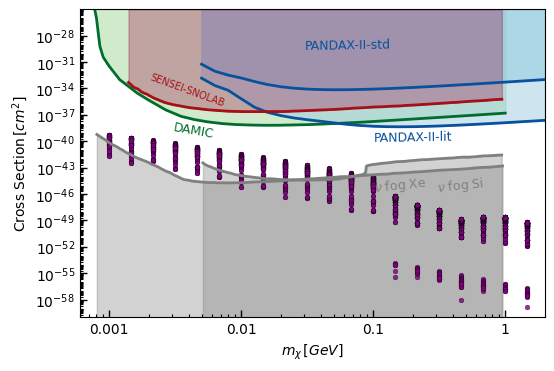

In [2]:
GEV2_TO_CM2 = 0.389379e-27   # 1 GeV^-2 to cm^2
M_N_GEV = 0.939              # nucleon mass = 0.939 GeV
F_N = 0.30                   # Hambye value for f = 0.3


def sigma_e(mx, r, gX, beta, mh1=125, vEW=246.0, me=0.511e-3):
    """
    σ_e with an electron in cm^2 
    """
    mh2=r*mx    
    num= ((np.sin(beta)*np.cos(beta))**2)*(me**4)*(mx**2)
    den= (vEW**2)*(me+mx)**2
    factor=( 1.0/(mh1**2)-1.0/(mh2)**2 )**2
    sig_gev2 = (gX**2)/(4*np.pi)*(num/den)*factor
    return sig_gev2 * GEV2_TO_CM2

#Values of sigma_e based on AnalyzeSweep
f1=("../data/SweepHiddenVector_Relic.csv")
relicPoints=pd.read_csv(f1).copy()

relicPoints["Sigma_e"]=sigma_e(relicPoints["mx"], relicPoints["r"], relicPoints["gX"], relicPoints["beta"], mh1=125, vEW=246.0,me=0.511e-3)
maskrelic=(relicPoints["mx"]<10)
relicPoints_clean=relicPoints[maskrelic]
vec1=relicPoints_clean["mx"]
vec2=relicPoints_clean["Sigma_e"]


#Bounds of DAMIC M
f_DAMIC=("../DirectDectection/DAMIC-M_2025_OFFICIALRESULT_QCDark_DMe_heavymediator.csv")
DAMIC=pd.read_csv(f_DAMIC,skiprows=1).copy()
DAMIC["mass_GeV"]=DAMIC["mass_ev"]*(1e-9)
DAMIC=DAMIC.rename(columns={"limit90CL_cm2":"sigma_e"})
x_DAMIC=DAMIC["mass_GeV"]
y_DAMIC=DAMIC["sigma_e"]

#Bounds of PANDA X-II
f_PANDAXII=("../DirectDectection/limitPandX-II.csv")
PANDAXII=pd.read_csv(f_PANDAXII).copy()
PANDAXII=PANDAXII.rename(columns={"DM mass [GeV]":"mass_GeV","limit_std [cm^2]":"limit_std_cm2","limit_lit [cm^2]":"limit_lit_cm2"})
x1_PANDAXII=PANDAXII["mass_GeV"]
y1_PANDAXII=PANDAXII["limit_std_cm2"]
y2_PANDAXII=PANDAXII["limit_lit_cm2"]


#Bounds SENSEI SNOLAB
f="../DirectDectection/SENSEI_SNOLAB.csv"
SENSEI=pd.read_csv(f).copy()
SENSEI=SENSEI.rename(columns={"x":"mass_MeV"," y":"sigma_e"})
SENSEI["mass_GeV"]=SENSEI["mass_MeV"]*1e-3
x1_SENSEI=SENSEI["mass_GeV"]
y2_SENSEI=SENSEI["sigma_e"]

# neutrino fog line Si
fnuSi="./ElectronScatteringNeutrinoSi.csv"
nufogSi=pd.read_csv(fnuSi).copy()
columnas=["mass_MeV","sigma_cm2"]
nufogSi.columns=columnas
nufogSi["mass_GeV"]=nufogSi["mass_MeV"]/1000.0
x_nuSi=nufogSi["mass_GeV"]
y_nuSi=nufogSi["sigma_cm2"]

# neutrino fog line Xe
fnuXe="./ElectronScatteringNeutrinoXe.csv"
nufogXe=pd.read_csv(fnuXe).copy()
columnas=["mass_MeV","Xegma_cm2"]
nufogXe.columns=columnas
nufogXe["mass_GeV"]=nufogXe["mass_MeV"]/1000.0
x_nuXe=nufogXe["mass_GeV"]
y_nuXe=nufogXe["Xegma_cm2"]

#Plot
fig,ax=plt.subplots(figsize=(6,4))

#Areas
ax.fill_between(x_DAMIC, y_DAMIC, 1e-25, alpha=0.5,color="#a1d99b",label="DAMIC")
ax.fill_between(x1_PANDAXII, y1_PANDAXII, 1e-25, alpha=0.5,color="#9ecae1",label="PANDAX-II-std")
ax.fill_between(x1_PANDAXII, y2_PANDAXII, 1e-25, alpha=0.5,color="#8ecae1",label="PANDAX-II-lit")
ax.fill_between(x1_SENSEI, y2_SENSEI, 1e-25, alpha=0.3,color="#9e0142",label="SENSEI-SNOLAB")


# expriments lines
ax.loglog(x_DAMIC,y_DAMIC,label="DAMIC",color="#006d2c",linewidth=2)
ax.loglog(x1_PANDAXII,y1_PANDAXII,label="PANDAX-II-std",color="#08519c",linewidth=2)
ax.loglog(x1_PANDAXII,y2_PANDAXII,label="PANDAX-II-lit",color="#09519c",linewidth=2)
ax.loglog(x1_SENSEI,y2_SENSEI,label="SENSEI-SNOLAB",color="#a50f15",linewidth=2)

# neutrino fog line Si
ax.loglog(x_nuSi, y_nuSi,color="gray",linewidth=2,label="neutrino fog Si")
ax.fill_between(x_nuSi,y_nuSi, 1e-60,color="gray",alpha=0.35,label="neutrino fog Si",zorder=0)

# neutrino fog line Xe
ax.loglog(x_nuXe, y_nuXe,color="gray",linewidth=2,label="neutrino fog Xe")
ax.fill_between(x_nuXe,y_nuXe, 1e-60,color="gray",alpha=0.35,label="neutrino fog Xe",zorder=0)

#Relic points
ax.scatter(vec1,vec2,s=12,color="purple",alpha=0.8,label="relic points",edgecolors="black", linewidths=0.25,)


#text on lines
ax.text(0.003, 3e-40, "DAMIC", fontsize=9, color="#006d2c", rotation=-10)
ax.text(0.03, 3e-30, "PANDAX-II-std", fontsize=9, color="#08519c", rotation=1)
ax.text(0.10, 1e-40, "PANDAX-II-lit", fontsize=9, color="#09519c", rotation=1)
ax.text(2e-3, 1e-36, "SENSEI-SNOLAB", fontsize=7, color="#a50f15", rotation=-20)
ax.text(0.3, 2e-46, r'$\nu$ fog Si', fontsize=9, color="gray", rotation=6)
ax.text(0.1, 2e-46, r'$\nu$ fog Xe', fontsize=9, color="gray", rotation=6)


ax.set_xlabel(r'$m_{\chi}\, [GeV]$')
ax.set_ylabel(r'$\text{Cross Section}\,[cm^2]$')


ax.set_xlim(0.0006, 2)
ax.set_ylim(1e-60, 1e-25)

xmaj = [1e-3, 1e-2, 1e-1, 1]
ymaj = 10.0**np.arange(-64, -25, 3)

ax.xaxis.set_major_locator(mticker.FixedLocator(xmaj))
ax.yaxis.set_major_locator(mticker.FixedLocator(ymaj))

#ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))

ax.xaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=1000)
)
ax.yaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=1000)
)

ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.tick_params(axis='both', which='major',
               direction='in',
               top=False, right=False,
               length=5, width=1.0)

ax.tick_params(axis='both', which='minor',
               direction='in',
               top=False, right=False,
               length=2.2, width=0.8)

#ax.legend(loc="upper right")
plt.savefig("direct_detection_1.pdf", bbox_inches="tight")
plt.show()




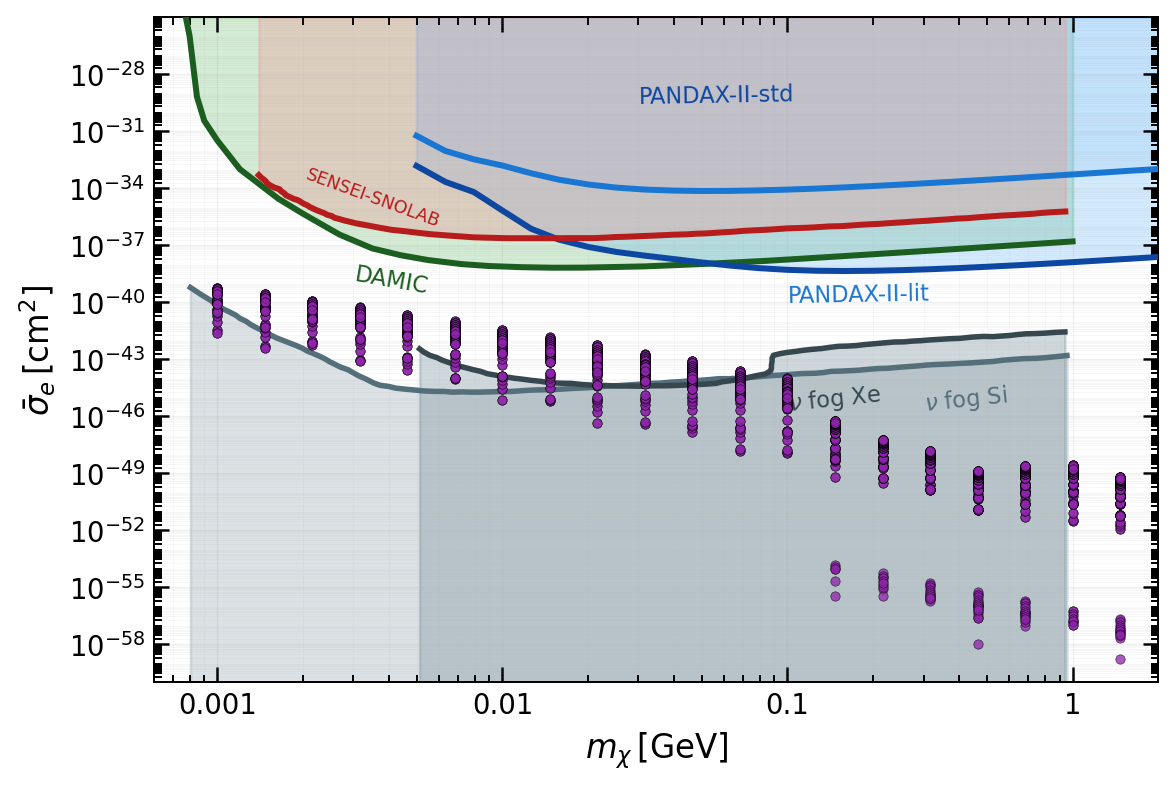

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=180)

# Areas excluidas
ax.fill_between(x_DAMIC, y_DAMIC, 1e-25,
                color="#81C784", alpha=0.35, zorder=1)

ax.fill_between(x1_PANDAXII, y1_PANDAXII, 1e-25,
                color="#64B5F6", alpha=0.28, zorder=1)

ax.fill_between(x1_PANDAXII, y2_PANDAXII, 1e-25,
                color="#90CAF9", alpha=0.25, zorder=1)

ax.fill_between(x1_SENSEI, y2_SENSEI, 1e-25,
                color="#EF9A9A", alpha=0.35, zorder=1)

# Neutrino fog
ax.fill_between(x_nuSi, y_nuSi, 1e-60,
                color="#B0BEC5", alpha=0.45, zorder=0)

ax.fill_between(x_nuXe, y_nuXe, 1e-60,
                color="#78909C", alpha=0.35, zorder=0)

# Líneas experimentales
ax.loglog(x_DAMIC, y_DAMIC,
          color="#1B5E20", linewidth=2.4, label="DAMIC", zorder=3)

ax.loglog(x1_PANDAXII, y1_PANDAXII,
          color="#0D47A1", linewidth=2.4, label="PANDAX-II-std", zorder=3)

ax.loglog(x1_PANDAXII, y2_PANDAXII,
          color="#1976D2", linewidth=2.4, label="PANDAX-II-lit", zorder=3)

ax.loglog(x1_SENSEI, y2_SENSEI,
          color="#B71C1C", linewidth=2.4, label="SENSEI-SNOLAB", zorder=3)

ax.loglog(x_nuSi, y_nuSi,
          color="#546E7A", linewidth=2.2, label=r"$\nu$ fog Si", zorder=2)

ax.loglog(x_nuXe, y_nuXe,
          color="#37474F", linewidth=2.2, label=r"$\nu$ fog Xe", zorder=2)

# Puntos del modelo
ax.scatter(vec1, vec2,
           s=14,
           color="#8E24AA",
           alpha=0.75,
           edgecolors="black",
           linewidths=0.25,
           label="Relic points",
           zorder=4)

# Textos
ax.text(0.003, 3e-40, "DAMIC",
        fontsize=9, color="#1B5E20", rotation=-10)

ax.text(0.03, 3e-30, "PANDAX-II-std",
        fontsize=9, color="#0D47A1", rotation=1)

ax.text(0.10, 1e-40, "PANDAX-II-lit",
        fontsize=9, color="#1976D2", rotation=1)

ax.text(2e-3, 1e-36, "SENSEI-SNOLAB",
        fontsize=7, color="#B71C1C", rotation=-20)

ax.text(0.3, 2e-46, r"$\nu$ fog Si",
        fontsize=9, color="#546E7A", rotation=6)

ax.text(0.1, 2e-46, r"$\nu$ fog Xe",
        fontsize=9, color="#37474F", rotation=6)

# Ejes
ax.set_xlabel(r"$m_{\chi}\,[\mathrm{GeV}]$", fontsize=13)
ax.set_ylabel(r"$\bar{\sigma}_{e}\,[\mathrm{cm}^{2}]$", fontsize=13)

ax.set_xlim(0.0006, 2)
ax.set_ylim(1e-60, 1e-25)

xmaj = [1e-3, 1e-2, 1e-1, 1]
ymaj = 10.0**np.arange(-58, -25, 3)

ax.xaxis.set_major_locator(mticker.FixedLocator(xmaj))
ax.yaxis.set_major_locator(mticker.FixedLocator(ymaj))

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))

ax.xaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=1000)
)

ax.yaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=1000)
)

ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.tick_params(axis="both", which="major",
               direction="in", top=True, right=True,
               length=6, width=1.0, labelsize=11)

ax.tick_params(axis="both", which="minor",
               direction="in", top=True, right=True,
               length=3, width=0.8)

ax.grid(True, which="major", alpha=0.20, linewidth=0.5)
ax.grid(True, which="minor", alpha=0.10, linewidth=0.35)

# ax.legend(frameon=False, fontsize=8, loc="upper right")

plt.savefig("direct_detection_1_pretty.pdf", bbox_inches="tight")
plt.show()

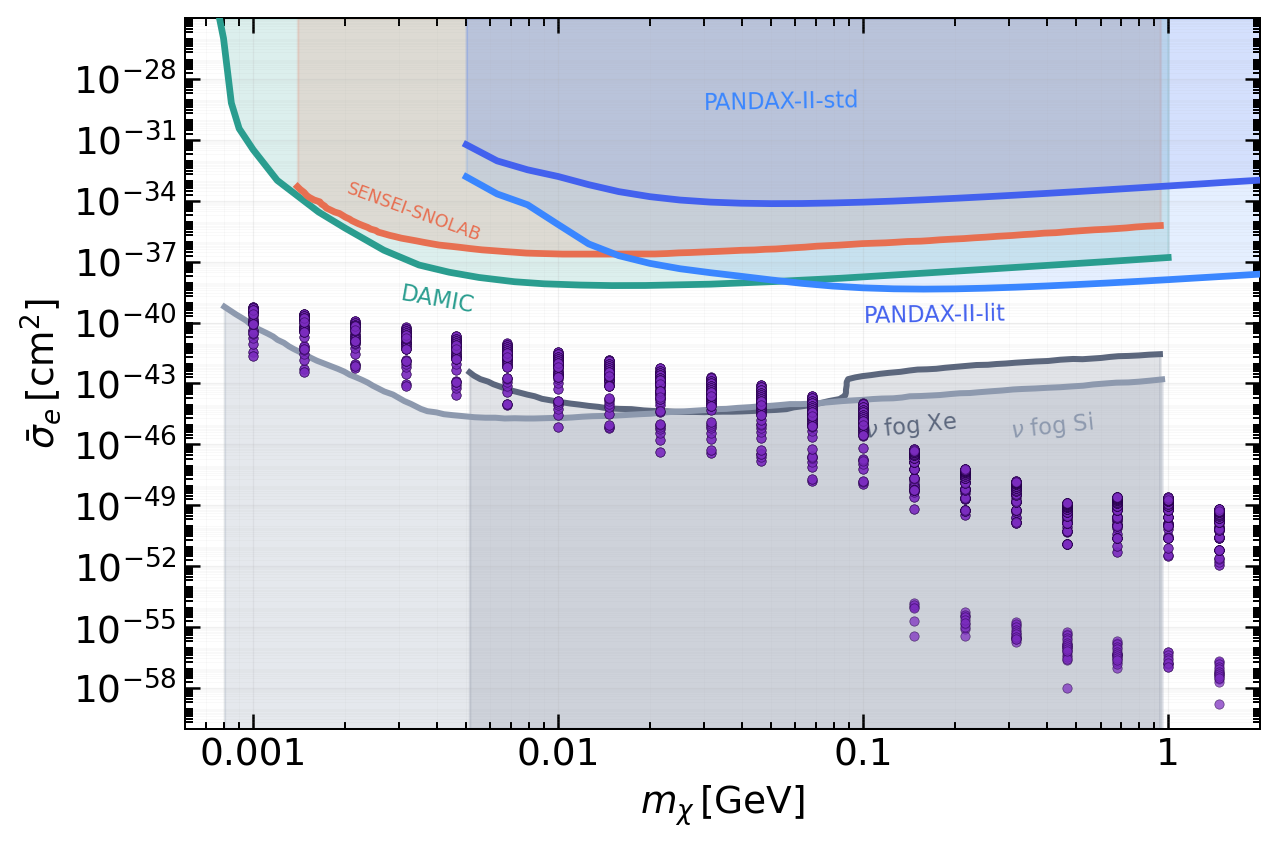

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=180)

# Paleta bonita y consistente
c_damic_line  = "#2A9D8F"
c_sensei_line = "#E76F51"
c_pandax_std  = "#3A86FF"
c_pandax_lit  = "#4361EE"
c_fog_xe      = "#5C677D"
c_fog_si      = "#8D99AE"
c_points      = "#7B2CBF"

# Áreas suaves
ax.fill_between(x_DAMIC, y_DAMIC, 1e-25,
                color=c_damic_line, alpha=0.16, zorder=1)

ax.fill_between(x1_SENSEI, y2_SENSEI, 1e-25,
                color=c_sensei_line, alpha=0.16, zorder=1)

ax.fill_between(x1_PANDAXII, y1_PANDAXII, 1e-25,
                color=c_pandax_std, alpha=0.13, zorder=1)

ax.fill_between(x1_PANDAXII, y2_PANDAXII, 1e-25,
                color=c_pandax_lit, alpha=0.10, zorder=1)

ax.fill_between(x_nuXe, y_nuXe, 1e-60,
                color=c_fog_xe, alpha=0.18, zorder=0)

ax.fill_between(x_nuSi, y_nuSi, 1e-60,
                color=c_fog_si, alpha=0.22, zorder=0)

# Líneas
ax.loglog(x_DAMIC, y_DAMIC,
          color=c_damic_line, linewidth=2.7, label="DAMIC", zorder=3)

ax.loglog(x1_SENSEI, y2_SENSEI,
          color=c_sensei_line, linewidth=2.7, label="SENSEI-SNOLAB", zorder=3)

ax.loglog(x1_PANDAXII, y1_PANDAXII,
          color=c_pandax_std, linewidth=2.7, label="PANDAX-II-std", zorder=3)

ax.loglog(x1_PANDAXII, y2_PANDAXII,
          color=c_pandax_lit, linewidth=2.7, label="PANDAX-II-lit", zorder=3)

ax.loglog(x_nuXe, y_nuXe,
          color=c_fog_xe, linewidth=2.4, label=r"$\nu$ fog Xe", zorder=2)

ax.loglog(x_nuSi, y_nuSi,
          color=c_fog_si, linewidth=2.4, label=r"$\nu$ fog Si", zorder=2)

# Puntos
ax.scatter(vec1, vec2,
           s=14,
           color=c_points,
           alpha=0.72,
           edgecolors="#240046",
           linewidths=0.25,
           label="Relic points",
           zorder=4)

# Textos
ax.text(0.003, 3e-40, "DAMIC",
        fontsize=9, color=c_damic_line, rotation=-10)

ax.text(0.03, 3e-30, "PANDAX-II-std",
        fontsize=9, color=c_pandax_std, rotation=1)

ax.text(0.10, 1e-40, "PANDAX-II-lit",
        fontsize=9, color=c_pandax_lit, rotation=1)

ax.text(2e-3, 1e-36, "SENSEI-SNOLAB",
        fontsize=7, color=c_sensei_line, rotation=-20)

ax.text(0.3, 2e-46, r"$\nu$ fog Si",
        fontsize=9, color=c_fog_si, rotation=6)

ax.text(0.1, 2e-46, r"$\nu$ fog Xe",
        fontsize=9, color=c_fog_xe, rotation=6)

# Ejes
ax.set_xlabel(r"$m_{\chi}\,[\mathrm{GeV}]$", fontsize=15)
ax.set_ylabel(r"$\bar{\sigma}_{e}\,[\mathrm{cm}^{2}]$", fontsize=15)

ax.set_xlim(0.0006, 2)
ax.set_ylim(1e-60, 1e-25)

xmaj = [1e-3, 1e-2, 1e-1, 1]
ymaj = 10.0**np.arange(-58, -25, 3)

ax.xaxis.set_major_locator(mticker.FixedLocator(xmaj))
ax.yaxis.set_major_locator(mticker.FixedLocator(ymaj))

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))

ax.xaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=1000)
)
ax.yaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=1000)
)

ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.tick_params(axis="both", which="major",
               direction="in", top=True, right=True,
               length=6, width=1.0, labelsize=15)

ax.tick_params(axis="both", which="minor",
               direction="in", top=True, right=True,
               length=3, width=0.8)

ax.grid(True, which="major", alpha=0.18, linewidth=0.5)
ax.grid(True, which="minor", alpha=0.08, linewidth=0.35)

plt.tight_layout()
plt.savefig("direct_detection_1_pretty.png", bbox_inches="tight")
plt.show()